<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("mathchi/churn-for-bank-customers")

100%|██████████| 261k/261k [00:00<00:00, 55.4MB/s]

Extracting files...


In [3]:
import pandas as pd
import os

# List the contents of the downloaded path to find the correct CSV file
files_in_path = os.listdir(path)
print(f"Files in the downloaded directory '{path}': {files_in_path}")

# Assuming 'Churn_Modelling.csv' is one of the files in the list, or we need to adjust
# For now, let's assume it might be directly in the path if the previous assumption was just a naming issue.
# If not, further inspection or user input will be needed to identify the correct file.

# Try to find a .csv file in the directory
csv_files = [f for f in files_in_path if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the correct one
    actual_csv_filename = csv_files[0]
    csv_file_path = os.path.join(path, actual_csv_filename)
    df = pd.read_csv(csv_file_path)

    print(f"Data loaded successfully from '{actual_csv_filename}'. First 5 rows of the DataFrame:\n{df.head()}")
    print(f"DataFrame shape: {df.shape}")
else:
    print("No CSV files found in the downloaded directory. Please check the dataset contents.")
    df = None # Set df to None or handle as appropriate if no CSV is found

Files in the downloaded directory '/root/.cache/kagglehub/datasets/mathchi/churn-for-bank-customers/versions/1': ['churn.csv']
Data loaded successfully from 'churn.csv'. First 5 rows of the DataFrame:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82    

In [4]:
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2562,2563,15646566,Bell,763,France,Female,58,9,187911.55,1,0,1,35825.18,0
4047,4048,15656707,Ma,720,Spain,Male,21,2,123200.78,1,1,1,180712.28,0
8880,8881,15603764,Chang,560,France,Male,49,4,0.00,1,1,1,100075.10,1


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop irrelevant features
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Identify features (X) and target (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

# Create a column transformer for one-hot encoding categorical features
# and passing numerical features through
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset preparation complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset preparation complete.
Shape of X_train: (8000, 13)
Shape of X_test: (2000, 13)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Train the model
print("Training Gradient Boosting Classifier...")
gbc.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Gradient Boosting Classifier...
Training complete.

Model Accuracy: 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


Confusion Matrix:
[[1537   56]
 [ 206  201]]


/tmp/ipykernel_2425/4089997664.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


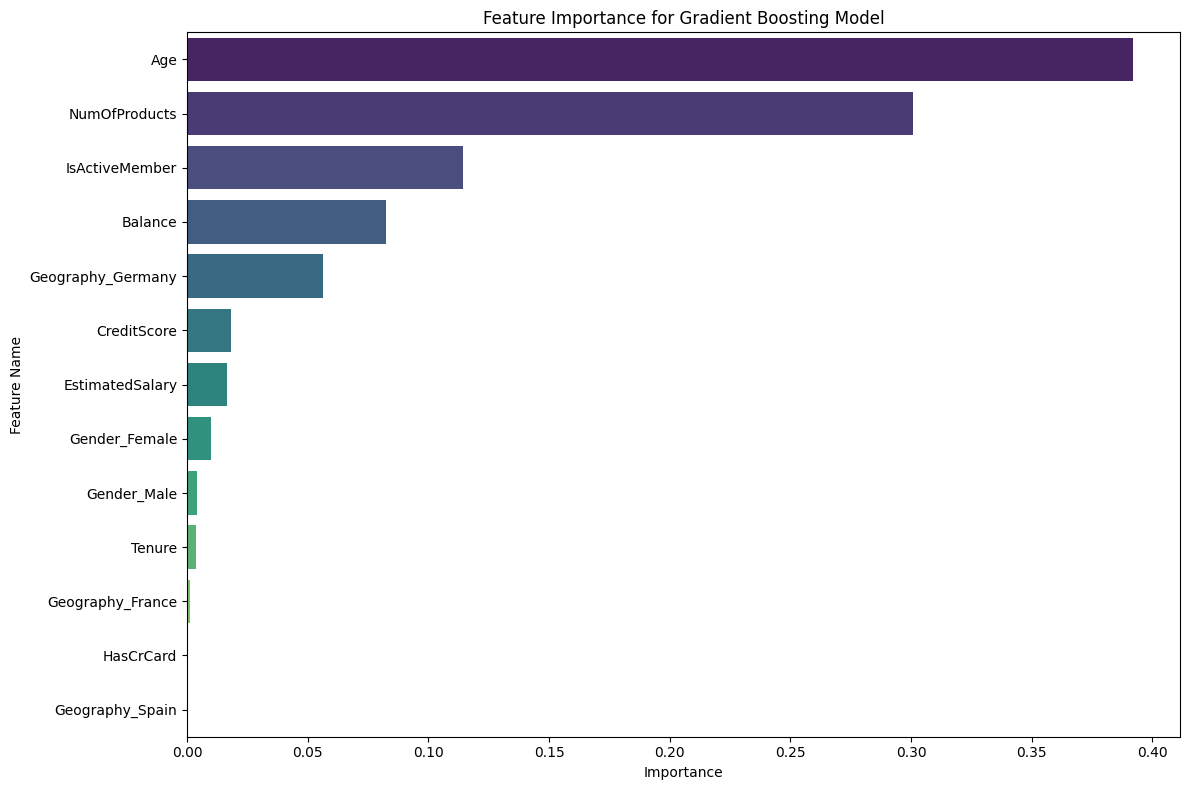

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature names after one-hot encoding
# Numerical features
feature_names = list(numerical_features)

# Categorical features after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get feature importances from the trained model
importances = gbc.feature_importances_

# Create a Series for easier handling and sorting
feature_importances = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Feature Importance for Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()